In [1]:
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'
from tabulate import tabulate

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report, r2_score, mean_absolute_error

# Utilitaires
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv")

In [3]:
# Test de quick_explore

def quick_explore(dataframe):
    """Exploration rapide d'un DataFrame"""
    print('##### Observer les lignes #####')
    display(dataframe.head(10))
    print('\n')

    print('##### Dimensions du dataset #####')
    print(f'Lignes : {dataframe.shape[0]}, Colonnes : {dataframe.shape[1]}')
    print('\n')

    print('##### Informations sur les colonnes #####')
    print(dataframe.info())
    print('\n')

    print('##### Noms des colonnes #####')
    print(list(dataframe.columns))
    print('\n')

    print('##### Valeurs uniques #####')
    print(dataframe.nunique())
    print('\n')

    print('##### Description des colonnes numériques #####')
    stats = dataframe.describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]).T
    print(stats.to_markdown())
    print('\n')

    print('##### Pourcentage de NaN par colonne #####')
    nan_percentage = (dataframe.isnull().sum() / len(dataframe)) * 100
    only_nan  = nan_percentage[nan_percentage > 0].sort_values(ascending=False)
    print(only_nan)
    print('\n')

    print('##### Nombre de doublons #####')
    print(dataframe.duplicated().sum(), 'doublon(s) trouvé(s)')
    print('\n')

    print('##### NaN par colonne #####')
    print(dataframe.isna().sum())

quick_explore(df)

##### Observer les lignes #####


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C




##### Dimensions du dataset #####
Lignes : 891, Colonnes : 12


##### Informations sur les colonnes #####
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.7 KB
None


##### Noms des colonnes #####
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarke

In [32]:
df = df.drop(columns='Embarked')

In [33]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,1,22,1,0,7.2500
1,2,1,1,0,38,1,0,71.2833
2,3,1,3,0,26,0,0,7.9250
3,4,1,1,0,35,1,0,53.1000
4,5,0,3,1,35,0,0,8.0500


In [ ]:
# Test de supp_nan

def supp_nan(df):
    df_clean = df.dropna()
    return df_clean

df_sans_nan = supp_nan(df)
df_sans_nan.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [6]:
# Test de fill_nan

def fill_nan(df):
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].fillna('Unknown')
    for col in df.select_dtypes(include='number').columns:
        df[col] = df[col].fillna(df[col].median())
    return df

df_remplacement_nan = fill_nan(df)
df_remplacement_nan.isna().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [9]:
# Test de convert_types

def convert_types(df, colonnes):
    """
    Utilisation : convert_types(df, {'colonne_a_convertir' : 'type_a_choisir, int, float, datetime, str, etc.'})
    """
    for col, type_ in colonnes.items():
        df[col] = df[col].astype(type_)
    return df

df_converti = convert_types(df, {'Age' : 'int'})
df_converti['Age']

0      22
1      38
2      26
3      35
4      35
       ..
886    27
887    19
888    28
889    26
890    32
Name: Age, Length: 891, dtype: int64

In [10]:
# Test de detect_outliers

def detect_outliers(df):
    for col in df.select_dtypes(include='number').columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'{col} : {len(outliers)} outliers')

df_outliers = detect_outliers(df)
df_outliers

Fare : 116 outliers


In [34]:
# Test de label_encoder

def label_encoder(df, colonnes):
    le = LabelEncoder()
    for col in colonnes:
        df[col] = le.fit_transform(df[col])
    return df

df_encode = label_encoder(df, ['Sex'])
df_encode

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,1,22,1,0,7.2500
1,2,1,1,0,38,1,0,71.2833
2,3,1,3,0,26,0,0,7.9250
3,4,1,1,0,35,1,0,53.1000
4,5,0,3,1,35,0,0,8.0500
...,...,...,...,...,...,...,...,...
886,887,0,2,1,27,0,0,13.0000
887,888,1,1,0,19,0,0,30.0000
888,889,0,3,0,28,1,2,23.4500
889,890,1,1,1,26,0,0,30.0000


In [35]:
# Test de split_xy

def split_xy(df, cible):
    X = df.drop(columns=cible)
    y = df[cible]
    return X, y

X, y = split_xy(df, ['Survived'])


In [36]:
# Test de traintestsplit

def traintestsplit(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = traintestsplit(X, y)

In [37]:
# Test de scaling

def scaling(X_train, X_test, methode='standard'):
    if methode == 'standard':
        scaler = StandardScaler()
    else:
        scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = scaling(X_train, X_test)

In [38]:
# Test de train_model

def train_model(X_train, y_train, modele='logistic'):
    """
    Utilisation : model = train_model(X_train, y_train)
    Modeles disponibles : 'logistic', 'decision_tree', 'random_forest', 'linear', 'KNN'
    """
    if modele == 'logistic':
        model = LogisticRegression()
    elif modele == 'decision_tree':
        model = DecisionTreeClassifier()
    elif modele == 'random_forest':
        model = RandomForestClassifier()
    elif modele == 'linear':
        model = LinearRegression()
    elif modele == 'KNN':
        model = KNeighborsClassifier()
    model.fit(X_train, y_train)
    return model

model = train_model(X_train, y_train)

In [39]:
# Test de predict

def predict(model, X_test):
    """
    Prédire les valeurs
    Utilisation : y_pred = predict(model, X_test_scaled)
    """
    return model.predict(X_test)

y_pred = predict(model, X_test)

In [41]:
# Test d'evaluation

def evaluation(y_test, y_pred, type_modele='classification'):
    """
    Evaluer un modèle ML
    Utilisation : evaluation(y_test, y_pred) => classification par défaut
    Regression : evaluation(y_test, y_pred, type_modele='regression')
    """
    if type_modele == 'classification':
        print(f'Accuracy : {accuracy_score(y_test, y_pred):.2f}')
        print(classification_report(y_test, y_pred))
    else :
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f'MSE : {mse:.2f}')
        print(f'MAE : {mae:.2f}')
        print(f'RMSE : {rmse:.2f}')
        print(f'R2_Score : {r2:.2f}')

evaluation(y_test, y_pred, type_modele = 'regression')

MSE : 0.22
MAE : 0.22
RMSE : 0.47
R2_Score : 0.08


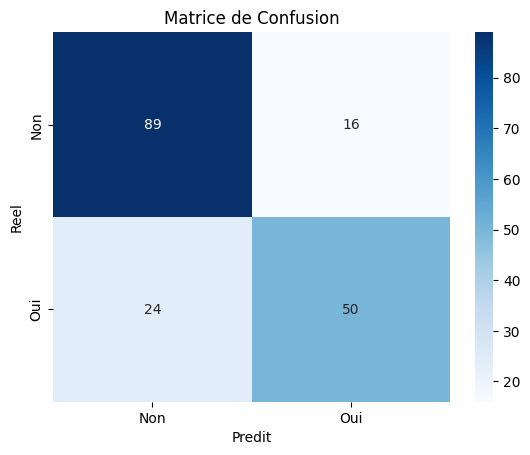

In [42]:
# Test de matrice de confusion

def matrice_confusion(y_test, y_pred, labels=None):
    """
    Afficher la matrice de confusion
    Avec labels : matrice_confusion(y_test, y_pred, labels=['Non', 'Oui'])
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predit')
    plt.ylabel('Reel')
    plt.title('Matrice de Confusion')
    plt.show()

matrice_confusion(y_test, y_pred, labels=['Non', 'Oui'])

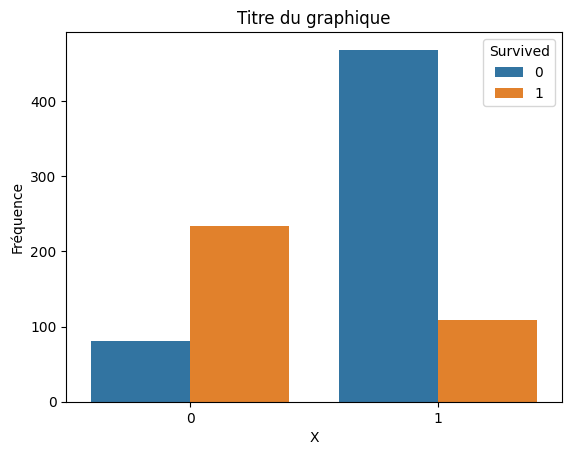

In [44]:
# Test de countplot

# sns_countplot : Diagramme en barres pour compter les catégories
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Titre du graphique')
plt.xlabel('X')
plt.ylabel('Fréquence')
plt.show()

# Oral : 'Ce graphique permet de voir la répartition des catégories. Avec hue, on peut voir comment la cible se distribue selon cette variable.'

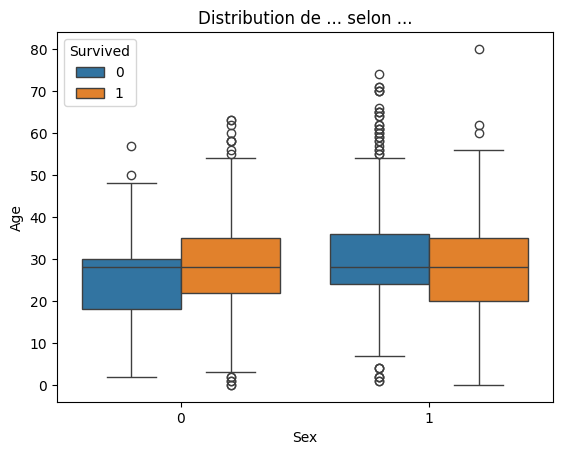

In [45]:
# Test de boxplot

# sns_boxplot : Visualise la distribution + outliers
sns.boxplot(data=df, x='Sex', y='Age', hue='Survived')
plt.title('Distribution de ... selon ...')
plt.show()

# Oral : 'Le boxplot montre la médiane, les quartiles et les outliers. Très utile pour comparer des distributions entre groupes.'

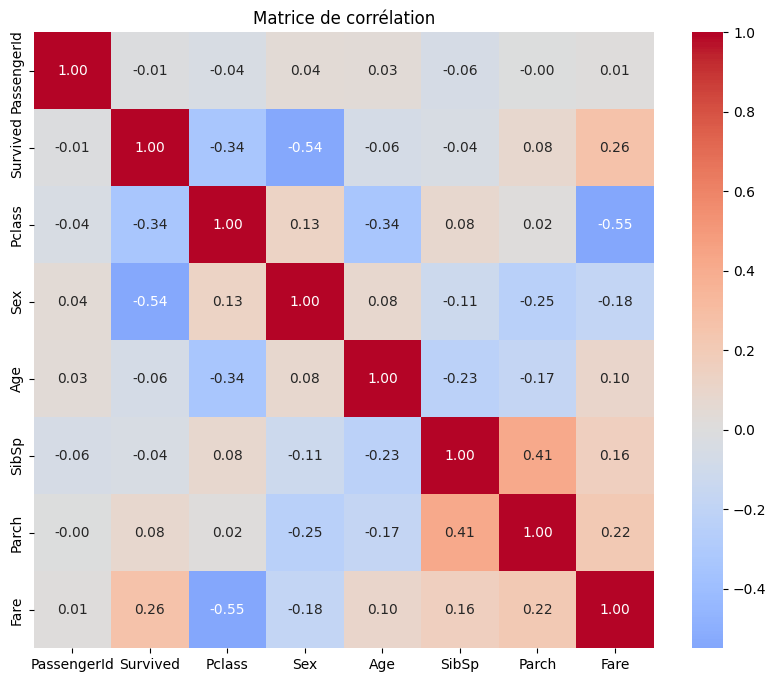

In [46]:
# Test de heatmap

# sns_heatmap : Matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

# Oral : 'Cette heatmap montre les corrélations entre variables numériques. Les couleurs chaudes = corrélation positive forte.'

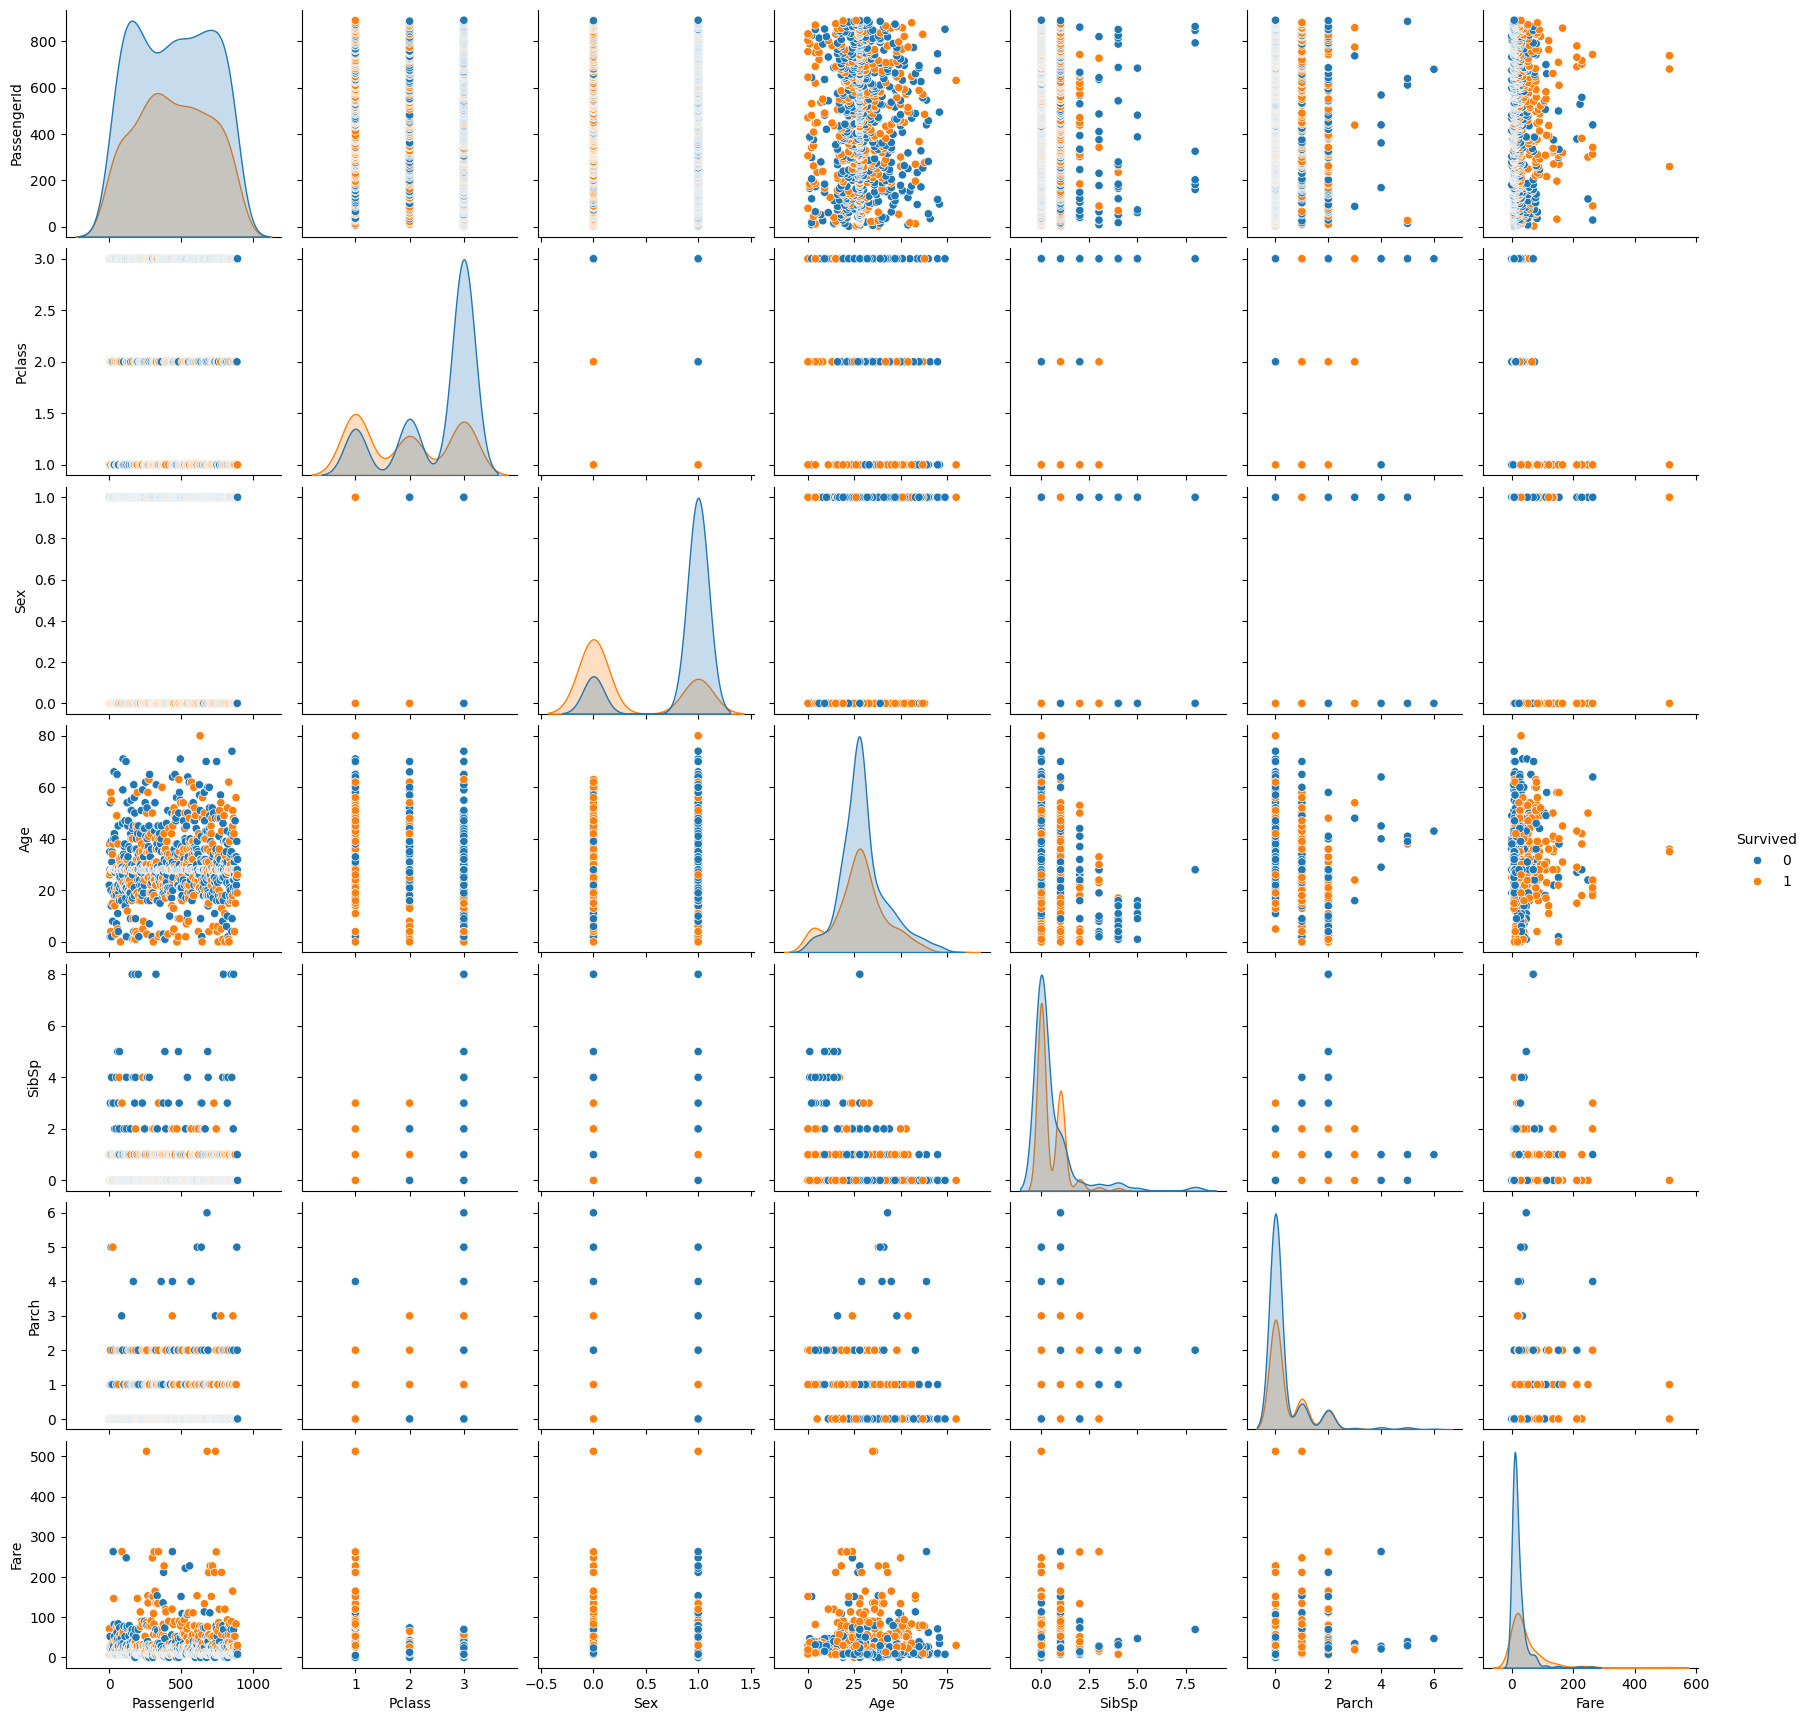

In [47]:
# Test de pairplot

# sns_pairplot : Vue d'ensemble de toutes les relations
sns.pairplot(df, hue='Survived', height=2.5, diag_kind='kde')
plt.show()

# Oral : 'Le pairplot est mon graphique préféré en phase d'exploration. Il montre toutes les relations bivariées + distributions en diagonale.'

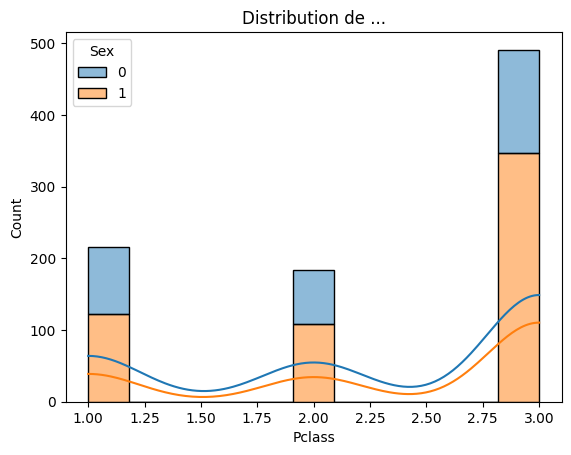

In [48]:
# Test de histplot

# sns_histplot : Histogramme avec densité
sns.histplot(data=df, x='Pclass', hue='Sex', kde=True, multiple='stack')
plt.title('Distribution de ...')
plt.show()

# Oral : 'Cet histogramme montre la distribution de la variable. Avec kde=True on voit la courbe de densité.'



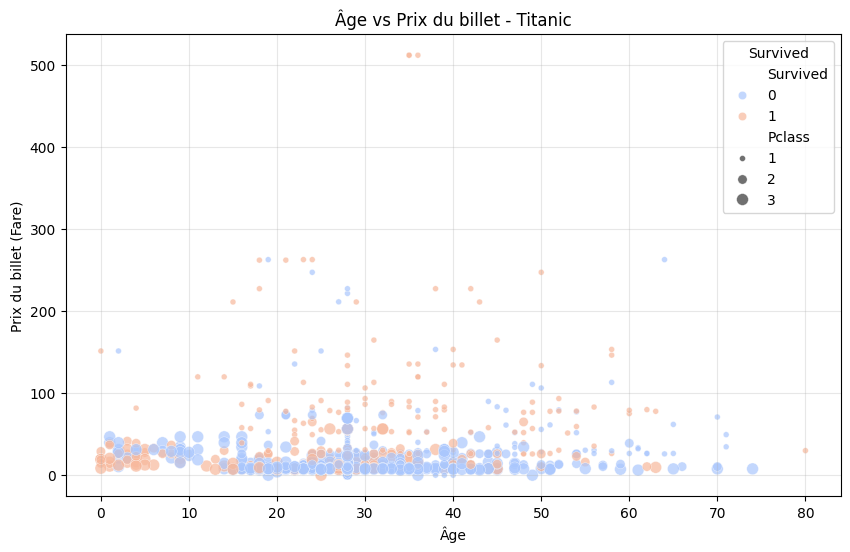

In [62]:
# Test de scatter

# Scatter simple et fiable avec Matplotlib + Seaborn
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, 
 x='Age', 
 y='Fare', 
 hue='Survived',
 size='Pclass',
 alpha=0.7,
 palette='coolwarm')

plt.title('Âge vs Prix du billet - Titanic')
plt.xlabel('Âge')
plt.ylabel('Prix du billet (Fare)')
plt.legend(title='Survived')
plt.grid(True, alpha=0.3)
plt.show()

# Oral : "Voici un scatter plot avec Seaborn. 
# On voit la relation entre l'âge et le prix du billet. 
# La couleur rouge/bleu indique si la personne a survécu. 
# La taille des points représente la classe."

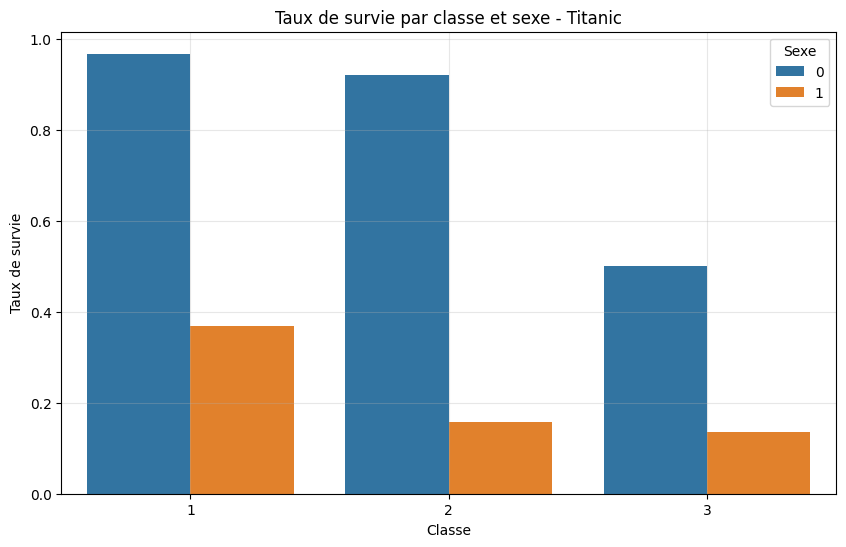

In [67]:
# Test de bar interactives

# Barres simples et fiables avec Seaborn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', ci=None)

plt.title('Taux de survie par classe et sexe - Titanic')
plt.xlabel('Classe')
plt.ylabel('Taux de survie')
plt.legend(title='Sexe')
plt.grid(True, alpha=0.3)
plt.show()

# Oral : "Ce diagramme en barres montre le taux de survie moyen par classe et par sexe. 
# On voit clairement que les femmes en 1ère classe ont le meilleur taux de survie."
# Oral : 'Ce bar chart interactif permet de comparer les valeurs entre catégories de façon claire et dynamique.'

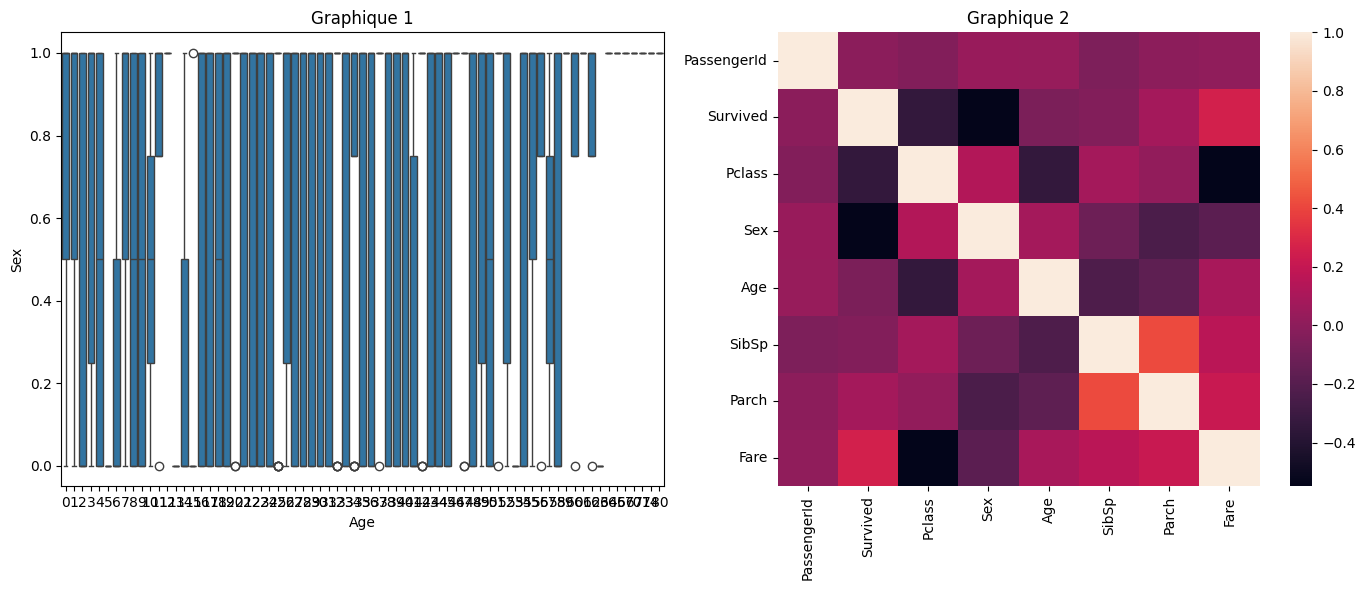

In [68]:
# Test de subplots

# subplots : Plusieurs graphiques sur une même figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Age', y='Sex', ax=axes[0])
sns.heatmap(df.corr(numeric_only=True), ax=axes[1])

axes[0].set_title('Graphique 1')
axes[1].set_title('Graphique 2')
plt.tight_layout()
plt.show()

# Oral : 'Avec subplots, je peux comparer plusieurs visualisations côte à côte pour une meilleure analyse.'

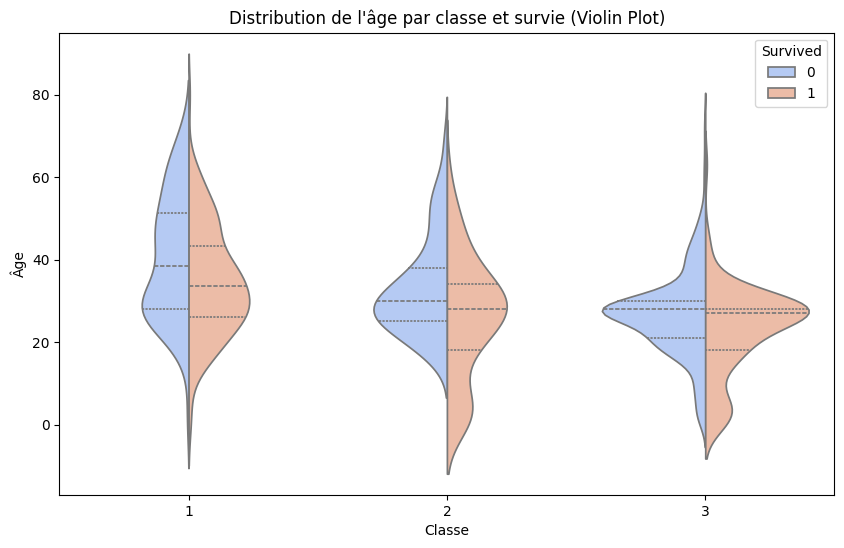

In [76]:
# Test de violinplot

# violinplot : Distribution détaillée + densité
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', 
 split=True, palette='coolwarm', inner='quart')

plt.title('Distribution de l\'âge par classe et survie (Violin Plot)')
plt.xlabel('Classe')
plt.ylabel('Âge')
plt.show()

# Oral : "Le violin plot combine un boxplot et une estimation de densité. 
# On voit à la fois la distribution globale et où se concentre l'âge pour chaque groupe."

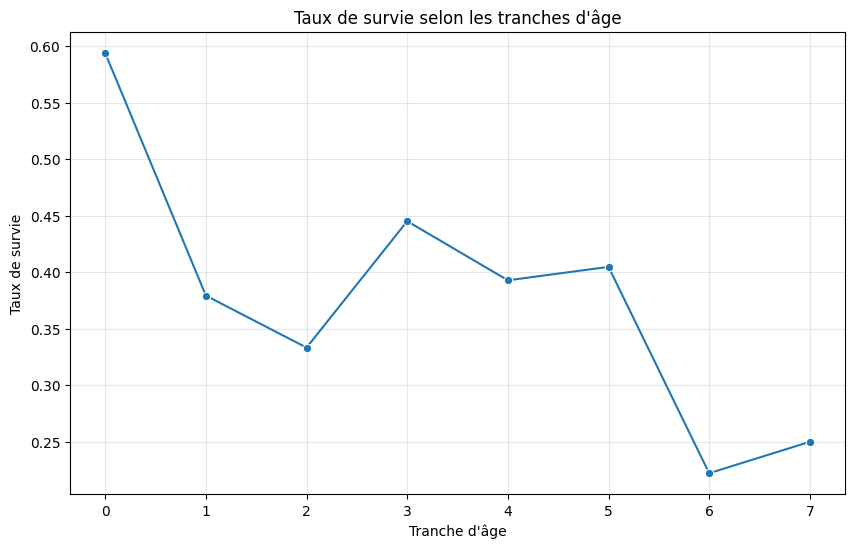

In [77]:
# Test de lineplot

# lineplot : Évolution ou tendance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Exemple : Taux de survie moyen par âge (par tranches)
df['AgeGroup'] = pd.cut(df['Age'], bins=8)
survival_by_age = df.groupby('AgeGroup', observed=True)['Survived'].mean().reset_index()

sns.lineplot(data=survival_by_age, x=survival_by_age.index, y='Survived', marker='o')

plt.title('Taux de survie selon les tranches d\'âge')
plt.xlabel('Tranche d\'âge')
plt.ylabel('Taux de survie')
plt.grid(True, alpha=0.3)
plt.show()

# Oral : "Ce line plot montre l'évolution du taux de survie en fonction de l'âge. 
# Utile pour visualiser des tendances sur une variable continue."